# Preparation phase

1.   **Data gathering**:
The datasets used for the analysis come from open sources:

* Migration statistics (inflows, outflows, net migration and related indicators):   
https://www.kaggle.com/datasets/nishanthsalian/international-migration-data-2000-2020
* World Bank indicators (demography, health, macro variables such as GDP and GDP per capita)
Macroeconomic data (inflation, unemployment, economic growth):
https://data360.worldbank.org/en/search?tab=dataset


*   Homicide data (intentional homicides per 100,000 people, reshaped from wide to long format):
https://data.worldbank.org/indicator/VC.IHR.PSRC.P5?utm_source=chatgpt.com
*   Crime statistics (various crime categories by sex, dimension, and category):
https://dataunodc.un.org/dp-crime-violent-offences



Thus, 5 datasets were obtained.Missing critical economic data were manually collected into 2 Excel tables and also uploaded. Sources:

*   https://www.imf.org/
*   https://ycharts.com/
*   https://fred.stlouisfed.org/
*   https://www.macrotrends.net/
*   https://chartingtheglobe.com/
*   https://www.worldometers.info/
*   https://countryeconomy.com/

2. **Preprossing data:**

Building a Unified Germany Dataset (2003–2020)
This notebook prepares a unified, analysis-ready dataset for Germany covering the years 2003–2020.
Multiple raw data sources are cleaned, reshaped, and merged into a single panel.

Key preprocessing steps include:



*   Creating a complete Year–Country backbone for Germany (2003–2020)
*   Harmonizing column formats and data types (especially the Year column)
*   Melting and pivoting homicide and crime data so that indicators become structured columns.
*   Merging all sources on Country and Year using left joins.
*   Dropping redundant or unused columns and exporting the final dataset as germany_data.csv.

3. **Objective:** To analyze the dependency of crime rates on the economic situation in Germany during the period from 2003 to 2020, forecast future crime volumes, and propose ideas for reducing the crimes committed.
4. **Analytics tools:**

*Data Preparation and Smoothing:*

Linear Interpolation

Log-linear Interpolation

Holt-Winters Exponential Smoothing

*Descriptive Statistics:*

Measures of Central Tendency: Mean, Median

Measures of Dispersion: Variance ($\text{var}$), Standard Deviation ($\text{std}$)

Measures of Distribution Shape: Skewness, Kurtosis

Time Series Visualization

*Correlation and Inferential Testing:*

Correlation Analysis (Correlation Matrices, Heatmaps)

Testing for Statistical Differences (One-way Analysis of Variance (ANOVA), T-test for Independent Samples)

*Regression and Modeling:*

Regression Analysis:
Multiple Linear Regression

Analysis of Regression Coefficients

Model Quality Assessment: $\text{R-squared}$, $\text{F-statistic}$, $\text{p-values}$, $\text{RMSE}$ (Root Mean Square Error)

Model Diagnostics: Omnibus, Durbin-Watson, Jarque-Bera, Condition Number

*Distribution Modeling for Rare Events:*

Poisson Distribution

Binomial Distribution

*Forecasting:*

Time Series Forecasting (ARIMA Model (Autoregressive Integrated Moving Average), Trend Extrapolation using $\text{CAGR}$ (Compound Annual Growth Rate))

Forecast Visualization (Actual, Predicted & Forecasted Plots)



### ⚠️ Warning: External API Dependency

The preprocessing steps rely on external statistical APIs, which are not always reachable
(due to rate limits, network issues, or temporary downtime).

If an error occurs **at any point**, run the fallback cell after **warning message bellow**
to continue the workflow without re-calling the APIs.

In [1]:
from google.colab import files
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from scipy.interpolate import interp1d
from scipy.stats import skew, kurtosis
from scipy.stats import norm, binom, poisson
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, f_oneway
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
import requests
from io import StringIO, BytesIO
import zipfile
from pandas_datareader import wb
import kagglehub
import os
import re

data_url = 'https://api.worldbank.org/v2/en/indicator/VC.IHR.PSRC.P5?downloadformat=csv'

response = requests.get(data_url)
response.raise_for_status()

zip_file = zipfile.ZipFile(BytesIO(response.content))

csv_file_name = None
for name in zip_file.namelist():
    if 'Metadata' not in name and name.endswith('.csv'):
        csv_file_name = name
        break
if csv_file_name is None and zip_file.namelist():
    csv_file_name = zip_file.namelist()[0]

if csv_file_name:
    with zip_file.open(csv_file_name) as csv_file:
        df_homicides_raw = pd.read_csv(csv_file, encoding='latin1', skiprows=4)
    print(f"Successfully loaded '{csv_file_name}' into a DataFrame.")
    print(df_homicides_raw.head())
else:
    print("No CSV file found in the zip archive.")
    print(zip_file.namelist())

Successfully loaded 'API_VC.IHR.PSRC.P5_DS2_en_csv_v2_3784.csv' into a DataFrame.
                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                               Indicator Name  Indicator Code  1960  1961  \
0  Intentional homicides (per 100,000 people)  VC.IHR.PSRC.P5   NaN   NaN   
1  Intentional homicides (per 100,000 people)  VC.IHR.PSRC.P5   NaN   NaN   
2  Intentional homicides (per 100,000 people)  VC.IHR.PSRC.P5   NaN   NaN   
3  Intentional homicides (per 100,000 people)  VC.IHR.PSRC.P5   NaN   NaN   
4  Intentional homicides (per 100,000 people)  VC.IHR.PSRC.P5   NaN   NaN   

   1962  1963  1964  1965  ...       2016       2017       2018       2019  \
0   NaN   NaN   NaN   NaN  ...        NaN        NaN        NaN        NaN   
1   NaN   NaN   

In [2]:
# Retrieving data forn period 2003-2020
year_cols = [str(y) for y in range(2003, 2021)]

# Select only Country Name + year columns
df_homicides_filtered = df_homicides_raw[["Country Name"] + ["Indicator Name"] + year_cols].copy()

# Rename Country Name -> Country for consistency with following data sets
df_homicides_filtered = df_homicides_filtered.rename(columns={"Country Name": "Country"})

df_homicides_filtered_germany_mask = df_homicides_filtered["Country"] == "Germany"

df_homicides_filtered_germany = df_homicides_filtered[df_homicides_filtered_germany_mask].reset_index(drop=True)
df_homicides_filtered_germany.head()

,Country,Indicator Name,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,Germany,"Intentional homicides (per 100,000 people)",1.335986,1.354566,1.272446,1.209273,1.092271,1.024525,0.992151,0.98106,0.912713,0.814421,0.841543,0.879865,0.830921,1.163604,0.978292,0.945201,0.745579,0.935086


In [3]:
# Downloading data on violent and sexual crimes per country from UN api
!wget 'https://dataunodc.un.org/sites/dataunodc.un.org/files/data_cts_violent_and_sexual_crime.xlsx'

--2025-12-06 07:07:35--  https://dataunodc.un.org/sites/dataunodc.un.org/files/data_cts_violent_and_sexual_crime.xlsx
Resolving dataunodc.un.org (dataunodc.un.org)... 157.150.185.69
Connecting to dataunodc.un.org (dataunodc.un.org)|157.150.185.69|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1406502 (1.3M) [application/vnd.openxmlformats-officedocument.spreadsheetml.sheet]
Saving to: ‘data_cts_violent_and_sexual_crime.xlsx’

data_cts_violent_an 100%[===================>]   1.34M  1.11MB/s    in 1.2s    

2025-12-06 07:07:37 (1.11 MB/s) - ‘data_cts_violent_and_sexual_crime.xlsx’ saved [1406502/1406502]



In [4]:
df_crimes_raw = pd.read_excel("data_cts_violent_and_sexual_crime.xlsx", header=2)

In [5]:
#  Getting data for Germany for period of 2003-2020 for these columns: Country,Indicator,Dimension,Category,Sex,Year,Unit of measurement,VALUE
df_crimes_raw_germany = df_crimes_raw[df_crimes_raw['Country'] == 'Germany']
cols_to_add = ["Indicator" ,"Dimension", "Category", "Sex", "Unit of measurement", "VALUE"]
df_crimes_filtered_germany = df_crimes_raw_germany[["Country"] + ["Year"] + cols_to_add].copy().reset_index(drop=True)
years_mask = (df_crimes_filtered_germany['Year'] >= 2003) & (df_crimes_filtered_germany['Year'] <= 2020)
df_crimes_filtered_germany_final = df_crimes_filtered_germany[years_mask]
df_crimes_filtered_germany_final.head(10)

,Country,Year,Indicator,Dimension,Category,Sex,Unit of measurement,VALUE
0,Germany,2003,Violent offences,by type of offence,Serious assault,Total,Counts,445727.0
1,Germany,2004,Violent offences,by type of offence,Serious assault,Total,Counts,474575.0
2,Germany,2005,Violent offences,by type of offence,Serious assault,Total,Counts,494329.0
3,Germany,2006,Violent offences,by type of offence,Serious assault,Total,Counts,510775.0
4,Germany,2007,Violent offences,by type of offence,Serious assault,Total,Counts,523283.0
5,Germany,2008,Violent offences,by type of offence,Serious assault,Total,Counts,518499.0
6,Germany,2009,Violent offences,by type of offence,Serious assault,Total,Counts,149301.0
7,Germany,2010,Violent offences,by type of offence,Serious assault,Total,Counts,142903.0
8,Germany,2011,Violent offences,by type of offence,Serious assault,Total,Counts,139091.0
9,Germany,2012,Violent offences,by type of offence,Serious assault,Total,Counts,136077.0


In [6]:
# Downloading data on migration from kaggle

path = kagglehub.dataset_download("nishanthsalian/international-migration-data-2000-2020")
print("Path to migration dataset files:", path)
print("\nDownloaded content:")
print(os.listdir(path))

100%|██████████| 35.3k/35.3k [00:00<00:00, 4.26MB/s]

Extracting files...
Path to migration dataset files: /root/.cache/kagglehub/datasets/nishanthsalian/international-migration-data-2000-2020/versions/1

Downloaded content:
['migration_2006.csv', 'migration_2000.csv', 'migration_2020.csv', 'migration_2001.csv', 'migration_2002.csv', 'migration_2018.csv', 'migration_2017.csv', 'migration_2019.csv', 'migration_2004.csv', 'migration_2016.csv', 'migration_2015.csv', 'migration_2005.csv', 'migration_2012.csv', 'migration_2014.csv', 'migration_2009.csv', 'migration_2008.csv', 'migration_2007.csv', 'migration_2003.csv', 'migration_2010.csv', 'migration_2011.csv', 'migration_2013.csv']


In [7]:
# Handling dowloaded datasets by year and combining them into single dataset
filenames = os.listdir(path)
all_dfs = []
for filename in filenames:
    if filename.endswith('.csv'):
        file_path = os.path.join(path, filename)
        df_year = pd.read_csv(file_path)

        # Extract year from filename and add it as a new column
        year = int(filename.split('_')[1].split('.')[0])
        df_year['Year'] = year

        all_dfs.append(df_year)

# Concatenate all dataframes into a single one
df_migration_raw = pd.concat(all_dfs, ignore_index=True)

print("Combined DataFrame `df_final` created. Displaying head:")
print(df_migration_raw.head().to_markdown(index=False))

Combined DataFrame `df_final` created. Displaying head:
| Country   |   Acquisition of nationality by country of former nationality(Total) |   Acquisition of nationality by country of former nationality(Women) |   Inflows of asylum seekers by nationality(Total) |   Inflows of asylum seekers by nationality(Women) |   Inflows of foreign population by nationality(Total) |   Inflows of foreign population by nationality(Women) |   Inflows of foreign workers by nationality(Total) |   Inflows of foreign workers by nationality(Women) |   Outflows of foreign population by nationality(Total) |   Outflows of foreign population by nationality(Women) |   Stock of foreign population by nationality(Total) |   Stock of foreign population by nationality(Women) |   Stock of foreign-born population by country of birth(Total) |   Stock of foreign-born population by country of birth(Women) |   Year |
|:----------|---------------------------------------------------------------------:|-----------------------

In [8]:
# Filtering combined dataset for Germany in 2003-2020 time range
germany_2003_2020_mask = (df_migration_raw['Country'] == 'Germany') & (df_migration_raw['Year'] >= 2003) & (df_migration_raw['Year'] <= 2020)
df_migration_final = df_migration_raw[germany_2003_2020_mask].sort_values(by='Year').reset_index(drop=True)
df_migration_final.head(20)

,Country,Acquisition of nationality by country of former nationality(Total),Acquisition of nationality by country of former nationality(Women),Inflows of asylum seekers by nationality(Total),Inflows of asylum seekers by nationality(Women),Inflows of foreign population by nationality(Total),Inflows of foreign population by nationality(Women),Inflows of foreign workers by nationality(Total),Inflows of foreign workers by nationality(Women),Outflows of foreign population by nationality(Total),Outflows of foreign population by nationality(Women),Stock of foreign population by nationality(Total),Stock of foreign population by nationality(Women),Stock of foreign-born population by country of birth(Total),Stock of foreign-born population by country of birth(Women),Year
0,Germany,140731.0,67632.0,50563.0,NaN,601759.0,253656.0,372172.0,NaN,499063.0,NaN,7335592.0,3408828.0,NaN,NaN,2003
1,Germany,127153.0,62593.0,35607.0,NaN,602182.0,250093.0,380330.0,NaN,546965.0,NaN,7334765.0,3439984.0,NaN,NaN,2004
2,Germany,117241.0,57318.0,28914.0,NaN,579301.0,239556.0,NaN,NaN,483584.0,NaN,6717115.0,3218705.0,NaN,NaN,2005
3,Germany,124566.0,61517.0,21029.0,NaN,558467.0,224744.0,30121.0,9435.0,483774.0,NaN,6755811.0,3262011.0,10371000.0,5179000.0,2006
4,Germany,113030.0,57019.0,19164.0,NaN,574752.0,231307.0,29208.0,9261.0,475752.0,NaN,6751004.0,3275731.0,10410000.0,5213000.0,2007
5,Germany,94470.0,47437.0,22085.0,NaN,573815.0,229306.0,30729.0,9317.0,563130.0,NaN,6744879.0,3285080.0,10505000.0,5279000.0,2008
6,Germany,96122.0,48549.0,27649.0,NaN,606314.0,244800.0,26245.0,8308.0,578808.0,NaN,6727618.0,3286336.0,10583000.0,5358000.0,2009
7,Germany,101570.0,51847.0,41332.0,NaN,683529.0,272343.0,NaN,NaN,529605.0,NaN,6694776.0,3282944.0,10557000.0,5369000.0,2010
8,Germany,106897.0,54815.0,45741.0,NaN,841695.0,327927.0,NaN,NaN,538837.0,195268.0,6753621.0,3311173.0,10551000.0,5368000.0,2011
9,Germany,112348.0,56551.0,64539.0,NaN,965908.0,377107.0,NaN,NaN,578759.0,205587.0,6930896.0,3384236.0,9807000.0,5056000.0,2012


In [9]:
# Downloading and handling economic data

path = kagglehub.dataset_download("adilshamim8/economic-indicators-and-inflation")
print("Path economic dataset files:", path)
print("\nDownloaded content:")
print(os.listdir(path))

100%|██████████| 1.07M/1.07M [00:00<00:00, 2.09MB/s]

Extracting files...
Path economic dataset files: /root/.cache/kagglehub/datasets/adilshamim8/economic-indicators-and-inflation/versions/5

Downloaded content:
['WorldBank.xlsx', 'Economic Indicators And Inflation.csv']


In [10]:
csv_file_path = os.path.join(path, 'Economic Indicators And Inflation.csv')
df_economic_raw = pd.read_csv(csv_file_path)
df_economic_raw_germany = df_economic_raw[df_economic_raw['Country'] == 'Germany'].reset_index(drop=True)
df_economic_raw_germany.drop(' GDP (in billion USD)', axis=1, inplace=True) # GDP data is taken from world bank dataset
years_mask = (df_economic_raw_germany[' Year'] >= 2003) & (df_economic_raw_germany[' Year'] <= 2020)
df_economic_raw_germany = df_economic_raw_germany[years_mask]
print("First 5 rows of df_economic_germany after dropping ' GDP (in billion USD)':")
df_economic_raw_germany.head()

First 5 rows of df_economic_germany after dropping ' GDP (in billion USD)':


,Country,Year,Inflation Rate (%),Unemployment Rate (%),Economic Growth (%)
0,Germany,2010,1.1,6.8,4.0
1,Germany,2011,2.3,6.5,3.6
2,Germany,2012,2.0,6.0,3.4
3,Germany,2013,1.4,5.8,3.5
4,Germany,2014,0.9,5.0,3.6


In [11]:
# Getting missing data for 2003-2009 years regarding Inflation Rate (%)	Unemployment Rate (%)	Economic Growth (%) in Germany
def clean_cols(df):
    df = df.copy()
    df.columns = df.columns.str.strip()
    return df

indicators = {
    "Inflation Rate (%)":      "FP.CPI.TOTL.ZG",
    "Unemployment Rate (%)":   "SL.UEM.TOTL.ZS",
    "Economic Growth (%)":     "NY.GDP.MKTP.KD.ZG",
}

# Germany = DEU, years 2003–2009
raw = wb.download(
    indicator=list(indicators.values()),
    country="DEU",
    start=2003,
    end=2009
)

df_economic_raw_germany_extra = raw.reset_index()   # columns: ['country', 'year', 'FP.CPI.TOTL.ZG', ...]
df_economic_raw_germany_extra = df_economic_raw_germany_extra.rename(columns={
    "country": "Country",
    "year": "Year",
    "FP.CPI.TOTL.ZG": "Inflation Rate (%)",
    "SL.UEM.TOTL.ZS": "Unemployment Rate (%)",
    "NY.GDP.MKTP.KD.ZG": "Economic Growth (%)",
})

df_economic_raw_germany_extra = clean_cols(df_economic_raw_germany_extra)
df_economic_raw_germany    = clean_cols(df_economic_raw_germany)

for d in (df_economic_raw_germany_extra, df_economic_raw_germany):
    if "index" in d.columns:
        d.drop(columns="index", inplace=True)

df_economic_germany = pd.concat(
    [df_economic_raw_germany_extra, df_economic_raw_germany],
    axis=0,
    ignore_index=True
).reset_index(drop=True)
df_economic_germany

/tmp/ipython-input-142228418.py:14: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  raw = wb.download(


,Country,Year,Inflation Rate (%),Unemployment Rate (%),Economic Growth (%)
0,Germany,2003,1.034222,9.779,-0.529929
1,Germany,2004,1.665737,10.727,1.162368
2,Germany,2005,1.546911,11.193,0.885697
3,Germany,2006,1.577426,10.277,3.855736
4,Germany,2007,2.298344,8.732,2.890107
5,Germany,2008,2.628380,7.508,0.910403
6,Germany,2009,0.312739,7.880,-5.545165
7,Germany,2010,1.100000,6.800,4.000000
8,Germany,2011,2.300000,6.500,3.600000
9,Germany,2012,2.000000,6.000,3.400000


In [12]:
# World Bank Data
excel_file_path = os.path.join(path, 'WorldBank.xlsx')
df_worldbank_raw = pd.read_excel(excel_file_path)
df_worldbank_raw_germany = df_worldbank_raw[df_worldbank_raw['Country Name'] == 'Germany'].sort_values(by='Year')
years_mask = (df_worldbank_raw_germany['Year'] >= 2003) & (df_worldbank_raw_germany['Year'] <= 2020)
df_worldbank_raw_germany = df_worldbank_raw_germany[years_mask].reset_index(drop=True)
print("First 5 rows of df_worldbank_germany:")
df_worldbank_raw_germany.head(20)

First 5 rows of df_worldbank_germany:


,Country Name,Country Code,Region,IncomeGroup,Year,"Birth rate, crude (per 1,000 people)","Death rate, crude (per 1,000 people)",Electric power consumption (kWh per capita),GDP (USD),GDP per capita (USD),Individuals using the Internet (% of population),"Infant mortality rate (per 1,000 live births)",Life expectancy at birth (years),Population density (people per sq. km of land area),Unemployment (% of total labor force) (modeled ILO estimate)
0,Germany,DEU,Europe & Central Asia,High income: OECD,2003,8.6,10.3,7009.73,2.510000e+12,30360.0,55.9000,4.1,78.3805,236.616,9.779
1,Germany,DEU,Europe & Central Asia,High income: OECD,2004,8.6,9.9,7108.96,2.820000e+12,34165.9,64.7300,4.0,78.6805,236.592,10.727
2,Germany,DEU,Europe & Central Asia,High income: OECD,2005,8.3,10.1,7138.22,2.860000e+12,34696.6,68.7100,3.9,78.9317,236.465,11.167
3,Germany,DEU,Europe & Central Asia,High income: OECD,2006,8.2,10.0,7212.44,3.000000e+12,36447.9,72.1600,3.8,79.1317,236.225,10.250
4,Germany,DEU,Europe & Central Asia,High income: OECD,2007,8.3,10.1,7229.09,3.440000e+12,41814.8,75.1600,3.7,79.5341,235.943,8.658
5,Germany,DEU,Europe & Central Asia,High income: OECD,2008,8.3,10.3,7187.76,3.750000e+12,45699.2,78.0000,3.6,79.7366,235.522,7.524
6,Germany,DEU,Europe & Central Asia,High income: OECD,2009,8.1,10.4,6817.16,3.420000e+12,41732.7,79.0000,3.5,79.8366,234.940,7.742
7,Germany,DEU,Europe & Central Asia,High income: OECD,2010,8.3,10.5,7264.32,3.420000e+12,41785.6,82.0000,3.5,79.9878,234.607,6.966
8,Germany,DEU,Europe & Central Asia,High income: OECD,2011,8.3,10.6,7281.27,3.760000e+12,46810.3,81.2700,3.4,80.4366,230.305,5.824
9,Germany,DEU,Europe & Central Asia,High income: OECD,2012,8.4,10.8,7270.15,3.540000e+12,44065.2,82.3500,3.4,80.5390,230.751,5.379


In [13]:
# Getting missing data for 2019-2020 years regarding various socio-economic parameters to add to df_worldbank_raw_germany

indicators = {
    "Birth rate, crude (per 1,000 people)": "SP.DYN.CBRT.IN",
    "Death rate, crude (per 1,000 people)": "SP.DYN.CDRT.IN",
    "Electric power consumption (kWh per capita)": "EG.USE.ELEC.KH.PC",
    "GDP (USD)": "NY.GDP.MKTP.CD",
    "GDP per capita (USD)": "NY.GDP.PCAP.CD",
    "Individuals using the Internet (% of population)": "IT.NET.USER.ZS",
    "Infant mortality rate (per 1,000 live births)": "SP.DYN.IMRT.IN",
    "Life expectancy at birth (years)": "SP.DYN.LE00.IN",
    "Population density (people per sq. km of land area)": "EN.POP.DNST",
    "Unemployment (% of total labor force) (modeled ILO estimate)": "SL.UEM.TOTL.ZS",
}

raw_19_20 = wb.download(
    indicator=list(indicators.values()),
    country="DEU",     # Germany
    start=2019,
    end=2020
)

raw_19_20.head()

df_19_20 = raw_19_20.reset_index()
df_19_20

rename_map = {
    "country": "Country Name",
    "year": "Year",
}

for nice_name, code in indicators.items():
    rename_map[code] = nice_name

# Adjusting new rows to initial format
df_19_20 = df_19_20.rename(columns=rename_map)
df_19_20["Country Code"] = "DEU"
df_19_20["Region"] = "Europe & Central Asia"
df_19_20["IncomeGroup"] = "High income: OECD"

cols_order = [
    "Country Name",
    "Country Code",
    "Region",
    "IncomeGroup",
    "Year",
    "Birth rate, crude (per 1,000 people)",
    "Death rate, crude (per 1,000 people)",
    "Electric power consumption (kWh per capita)",
    "GDP (USD)",
    "GDP per capita (USD)",
    "Individuals using the Internet (% of population)",
    "Infant mortality rate (per 1,000 live births)",
    "Life expectancy at birth (years)",
    "Population density (people per sq. km of land area)",
    "Unemployment (% of total labor force) (modeled ILO estimate)",
]

df_19_20 = df_19_20[cols_order].sort_values("Year").reset_index(drop=True)

df_worldbank_raw_germany.columns = df_worldbank_raw_germany.columns.str.strip()
df_19_20.columns = df_19_20.columns.str.strip()

df_worldbank_germany = pd.concat(
    [df_worldbank_raw_germany, df_19_20],
    axis=0,
    ignore_index=True
).reset_index(drop=True)

/tmp/ipython-input-78597684.py:16: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  raw_19_20 = wb.download(


In [14]:
df_worldbank_germany = (
    df_worldbank_germany
    .rename(columns={"Country Name": "Country"})
    .drop(columns=["Country Code", "Region", "IncomeGroup"])
)
df_worldbank_germany.tail(5)

,Country,Year,"Birth rate, crude (per 1,000 people)","Death rate, crude (per 1,000 people)",Electric power consumption (kWh per capita),GDP (USD),GDP per capita (USD),Individuals using the Internet (% of population),"Infant mortality rate (per 1,000 live births)",Life expectancy at birth (years),Population density (people per sq. km of land area),Unemployment (% of total labor force) (modeled ILO estimate)
13,Germany,2016,9.6,11.1,NaN,3.500000e+12,42443.500000,84.1652,3.2,80.990200,235.713000,4.122
14,Germany,2017,9.5,11.3,NaN,3.690000e+12,44681.100000,84.3955,3.2,80.990200,236.595000,3.746
15,Germany,2018,NaN,NaN,NaN,4.000000e+12,48195.600000,89.7391,3.1,NaN,237.371000,3.425
16,Germany,2019,9.4,11.3,6580.292564,3.957208e+12,47623.865607,88.1345,3.1,81.292683,237.822954,3.163
17,Germany,2020,9.3,11.9,6367.105029,3.940143e+12,47379.765195,89.8129,3.1,81.041463,238.017319,3.881


In [15]:
# Merging all Data Sets into One

# Make explicit copies so we don't accidentally modify the original dataframes
df_germany_wb = df_worldbank_germany.copy()
df_germany_economy = df_economic_germany.copy()
df_germany_migration = df_migration_final.copy()
df_germany_crimes = df_crimes_filtered_germany_final.copy()
df_germany_homicides = df_homicides_filtered_germany.copy()

# Create a base dataframe with one row per Year and Country (Germany, 2003–2020)
years = pd.DataFrame({"Year": list(range(2003, 2021))})
years["Country"] = "Germany"

# Make sure Year is integer for consistent merging
df_germany_wb["Year"] = df_germany_wb["Year"].astype(int)

# Start building the final dataset: base (years) + World Bank macro data
df_final = years.merge(df_germany_wb, on=["Country", "Year"], how="left")
df_germany_economy["Year"] = df_germany_economy["Year"].astype(int)
df_final = df_final.merge(
    df_germany_economy,
    on=["Country", "Year"],
    how="left",
)

# Reshape homicide data from wide format (years as columns) to long format (Year column)
kill_melt = df_germany_homicides.melt(
    id_vars=["Country", "Indicator Name"],
    var_name="Year",
    value_name="Intentional homicides (per 100,000 people)"
).drop(columns=["Indicator Name"])
kill_melt["Year"] = kill_melt["Year"].astype(int)

df_final = df_final.merge(
    kill_melt,
    on=["Country", "Year"],
    how="left"
)

# Align Year type and merge migration data (inflows / outflows / net migration)
df_germany_migration["Year"] = df_germany_migration["Year"].astype(int)
df_final = df_final.merge(
    df_germany_migration,
    on=["Country", "Year"],
    how="left"
)

df_germany_crimes["Year"] = df_germany_crimes["Year"].astype(int)

# Pivot crime data so that each crime/indicator combination becomes a separate column
crimes_pivot = df_germany_crimes.pivot_table(
    index=["Country", "Year"],
    columns=["Indicator", "Dimension", "Category", "Sex"],
    values="VALUE",
    aggfunc="first"
)

crimes_pivot.columns = [
    "Crimes_" + "_".join(map(str, col)).replace(" ", "_")
    for col in crimes_pivot.columns
]
crimes_pivot = crimes_pivot.reset_index()

df_final = df_final.merge(
    crimes_pivot,
    on=["Country", "Year"],
    how="left"
)

df_final = df_final.sort_values("Year").reset_index(drop=True)

#  Reorder columns so that Country and Year appear first
cols = df_final.columns.tolist()
cols = ["Country", "Year"] + [c for c in cols if c not in ["Country", "Year"]]
df_final = df_final[cols]

cols_to_drop = [
    "Country",
    "Electric power consumption (kWh per capita)",
    "Unemployment (% of total labor force) (modeled ILO estimate)",
]
df_full = df_final.drop(columns=cols_to_drop)

print(df_full.shape)
df_full.to_csv("germany_data.csv")

(18, 52)


## ⚠️ Warning: Data Preprocessing May Fail

Data preprocessing in this notebook depends on external statistical APIs.  
These services can occasionally be unavailable or unstable, which may cause errors in the cells above.

If you encounter any errors **before this point**, please start running notebook from the fallback cell below
to load the prepared data and proceed without relying on the APIs.

In [16]:
try:
    path = kagglehub.dataset_download("paulbruk/germany-social-economic-indicators-20032020")
    print("Path to dataset files:", path)
    csv_path = os.path.join(path, "germany.csv")
    df_fallback = pd.read_csv(csv_path)
    if not df_full.empty:
        print("\nSuccessfully retrieved original data, processing...\n")
        df = pd.read_csv("germany_data.csv")
    else:
        print("df_full exists but is empty")
        print("\nOriginal Data are not available, will use fallback set:\n")
        df = df_fallback.copy()
except NameError:
    print("df_full is not defined")

100%|██████████| 3.13k/3.13k [00:00<00:00, 6.42MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/paulbruk/germany-social-economic-indicators-20032020/versions/1

Successfully retrieved original data, processing...



In [17]:
df.head()

,Unnamed: 0,Year,"Birth rate, crude (per 1,000 people)","Death rate, crude (per 1,000 people)",GDP (USD),GDP per capita (USD),Individuals using the Internet (% of population),"Infant mortality rate (per 1,000 live births)",Life expectancy at birth (years),Population density (people per sq. km of land area),...,Crimes_Victims_of_sexual_violence_by_relationship_to_perpetrator_Relationship_to_perpetrator_is_not_known_Male,Crimes_Violent_offences_by_type_of_offence_Acts_intended_to_induce_fear_or_emotional_distress_Total,Crimes_Violent_offences_by_type_of_offence_Acts_intended_to_induce_fear_or_emotional_distress:_Cyber-related_Total,Crimes_Violent_offences_by_type_of_offence_Kidnapping_Total,Crimes_Violent_offences_by_type_of_offence_Serious_assault_Total,Crimes_Violent_offences_by_type_of_offence_Sexual_Exploitation_Total,Crimes_Violent_offences_by_type_of_offence_Sexual_violence_Total,Crimes_Violent_offences_by_type_of_offence_Sexual_violence:_Other_acts_of_sexual_violence_Total,Crimes_Violent_offences_by_type_of_offence_Sexual_violence:_Rape_Total,Crimes_Violent_offences_by_type_of_offence_Sexual_violence:_Sexual_assault_Total
0,0,2003,8.6,10.3,2.510000e+12,30360.0,55.90,4.1,78.3805,236.616,...,NaN,NaN,NaN,NaN,445727.0,NaN,54632.0,NaN,8766.0,NaN
1,1,2004,8.6,9.9,2.820000e+12,34165.9,64.73,4.0,78.6805,236.592,...,NaN,NaN,NaN,1830.0,474575.0,NaN,57306.0,NaN,8831.0,NaN
2,2,2005,8.3,10.1,2.860000e+12,34696.6,68.71,3.9,78.9317,236.465,...,NaN,NaN,NaN,1727.0,494329.0,NaN,55203.0,NaN,8133.0,NaN
3,3,2006,8.2,10.0,3.000000e+12,36447.9,72.16,3.8,79.1317,236.225,...,NaN,NaN,NaN,1596.0,510775.0,NaN,52231.0,NaN,8118.0,NaN
4,4,2007,8.3,10.1,3.440000e+12,41814.8,75.16,3.7,79.5341,235.943,...,NaN,NaN,NaN,1825.0,523283.0,NaN,56281.0,NaN,7511.0,NaN


In [18]:
print(df.shape)

(18, 53)


In [19]:
df.columns

Index(['Unnamed: 0', 'Year', 'Birth rate, crude (per 1,000 people)',
       'Death rate, crude (per 1,000 people)', 'GDP (USD)',
       'GDP per capita (USD)',
       'Individuals using the Internet (% of population)',
       'Infant mortality rate (per 1,000 live births)',
       'Life expectancy at birth (years)',
       'Population density (people per sq. km of land area)',
       'Inflation Rate (%)', 'Unemployment Rate (%)', 'Economic Growth (%)',
       'Intentional homicides (per 100,000 people)',
       'Acquisition of nationality by country of former nationality(Total)',
       'Acquisition of nationality by country of former nationality(Women)',
       'Inflows of asylum seekers by nationality(Total)',
       'Inflows of asylum seekers by nationality(Women)',
       'Inflows of foreign population by nationality(Total)',
       'Inflows of foreign population by nationality(Women)',
       'Inflows of foreign workers by nationality(Total)',
       'Inflows of foreign workers by

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 53 columns):
 #   Column                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                              --------------  -----  
 0   Unnamed: 0                                                                                                          18 non-null     int64  
 1   Year                                                                                                                18 non-null     int64  
 2   Birth rate, crude (per 1,000 people)                                                                                17 non-null     float64
 3   Death rate, crude (per 1,000 people)                                                                                17 non-null     float64
 4   GDP (USD)             

In [21]:
df.isnull().sum()

,0
Unnamed: 0,0
Year,0
"Birth rate, crude (per 1,000 people)",1
"Death rate, crude (per 1,000 people)",1
GDP (USD),0
GDP per capita (USD),0
Individuals using the Internet (% of population),0
"Infant mortality rate (per 1,000 live births)",0
Life expectancy at birth (years),1
Population density (people per sq. km of land area),0





---


---



# Data Cleaning

In [22]:
cols_to_drop = [
    'Crimes_Violent_offences_by_type_of_offence_Sexual_violence:_Other_acts_of_sexual_violence_Total',
    'Inflows of asylum seekers by nationality(Women)',
    'Unnamed: 0',
    'Inflows of foreign workers by nationality(Women)',
    'Inflows of foreign workers by nationality(Total)',
    'Crimes_Violent_offences_by_type_of_offence_Sexual_Exploitation_Total',
    'Crimes_Violent_offences_by_type_of_offence_Acts_intended_to_induce_fear_or_emotional_distress:_Cyber-related_Total',
    'Crimes_Violent_offences_by_type_of_offence_Acts_intended_to_induce_fear_or_emotional_distress_Total', # Added comma
    'Outflows of foreign population by nationality(Women)',
    'Stock of foreign-born population by country of birth(Total)',
    'Stock of foreign-born population by country of birth(Women)'
]

df = df.drop(columns=cols_to_drop, errors='ignore')

# Data Imputation

**1.Demographic Indicators**

*linear interpolation*

These indicators change gradually over time

Trends are smooth and predictable

This is the standard approach (World Bank, OECD)

In [23]:
# List of demographic columns to fill using linear interpolation
demographic_columns = [
    'Birth rate, crude (per 1,000 people)',
    'Death rate, crude (per 1,000 people)',
    'Life expectancy at birth (years)',
    'Infant mortality rate (per 1,000 live births)'
]

for col in demographic_columns:
    if col in df.columns:
        df[col] = df[col].interpolate(method='linear')
    else:
        print(f"Column not found: {col}")

print("Linear interpolation completed for demographic indicators.")


Linear interpolation completed for demographic indicators.


**2. Economic Indicators (GDP)**

*Log-linear interpolation*

better for exponential growth

In [24]:
# List of GDP-related columns to fill using log-linear interpolation
gdp_columns = [
    'GDP (USD)',
    'GDP per capita (USD)'
]

for col in gdp_columns:
    if col in df.columns:
        df[col] = np.exp(np.log(df[col].replace(0, np.nan)).interpolate(method='linear'))
    else:
        print(f"Column not found: {col}")

print("Log-linear interpolation completed for GDP indicators.")


Log-linear interpolation completed for GDP indicators.


**3.Migration Data**

*Linear interpolation*

(Best method if missing ≤ 3 consecutive years)

Holt-Winters Exponential Smoothing

(Best method if missing many years (4–10))

In [25]:
# List of columns with migration data
migration_columns = [
    'Acquisition of nationality by country of former nationality(Total)',
    'Acquisition of nationality by country of former nationality(Women)',
    'Inflows of asylum seekers by nationality(Total)',
    'Inflows of foreign population by nationality(Total)',
    'Inflows of foreign population by nationality(Women)',
    'Outflows of foreign population by nationality(Total)',
    'Stock of foreign population by nationality(Total)',
    'Stock of foreign population by nationality(Women)'
]

for col in migration_columns:
    if col in df.columns:
        series = df[col]

        # Find the maximum number of consecutive missing values
        is_na = series.isna().astype(int)
        max_gap = (is_na.groupby((is_na != is_na.shift()).cumsum()).cumsum() * is_na).max()

        if max_gap <= 3:
            # Linear interpolation for short gaps
            df[col] = series.interpolate(method='linear')
            print(f"{col}: linear interpolation applied (max gap {max_gap})")
        else:
            # Holt-Winters for long gaps
            try:
                model = ExponentialSmoothing(series, trend='add', seasonal=None).fit(optimized=False)
                df[col] = series.fillna(model.fittedvalues)
                print(f"{col}: Holt-Winters applied (max gap {max_gap})")
            except Exception as e:
                print(f"Could not apply Holt-Winters for {col}: {e}")
    else:
        print(f"Column not found: {col}")

print("Migration data interpolation completed.")


Acquisition of nationality by country of former nationality(Total): linear interpolation applied (max gap 1)
Acquisition of nationality by country of former nationality(Women): linear interpolation applied (max gap 2)
Inflows of asylum seekers by nationality(Total): linear interpolation applied (max gap 1)
Inflows of foreign population by nationality(Total): linear interpolation applied (max gap 2)
Inflows of foreign population by nationality(Women): linear interpolation applied (max gap 2)
Outflows of foreign population by nationality(Total): linear interpolation applied (max gap 2)
Stock of foreign population by nationality(Total): linear interpolation applied (max gap 1)
Stock of foreign population by nationality(Women): linear interpolation applied (max gap 1)
Migration data interpolation completed.


**4.Crime Statistics (Violent offences, sexual violence, kidnapping)**

*Holt-Winters exponential smoothing*

*Linear interpolation distorts peaks*

Crime data often fluctuates unpredictably

Exponential smoothing preserves underlying patterns

This is the recommended method by UNODC / Eurostat

In [26]:
# Define the list of columns for additional checking/imputation
# These are columns identified for specific imputation treatment
new_crime_columns = [
    'Crimes_Violent_offences_by_type_of_offence_Sexual_violence:_Sexual_assault_Total',
    'Crimes_Violent_offences_by_type_of_offence_Kidnapping_Total'
]

# List of columns to undergo imputation
# 1. Identify crime-related columns with missing values that fit the Holt-Winters criteria (starting with 'Crimes_Victims_of')
crime_victim_columns = [
    col for col in df.columns if col.startswith('Crimes_Victims_of') and df[col].isnull().any()
]

# 2. Add the specific violent crime columns if they exist and have missing values
for new_col in new_crime_columns:
    if new_col in df.columns and df[new_col].isnull().any():
        crime_victim_columns.append(new_col)
        print(f"Added column '{new_col}' to the imputation list.")
    elif new_col in df.columns:
        print(f"Column '{new_col}' is present but has no missing values, skipping imputation for it.")
    else:
        print(f"Column '{new_col}' not found in the DataFrame. Skipping.")

# Applying imputation
for col in crime_victim_columns:
    print(f"\nProcessing column: {col}")

    # Step 1: Handle NaNs at the edges for Holt-Winters compatibility
    # Make a copy of the series
    series = df[col].copy()

    # Perform linear interpolation on NaNs at the beginning/end
    # This is necessary for compatibility with Holt-Winters, which does not work with NaNs at the edges
    series_temp = series.interpolate(method='linear', limit_direction='both')

    # Step 2: Apply Holt-Winters for remaining gaps with optimization
    try:
        # Checking for a sufficient amount of data
        # Check if there is at least one non-NaN value after edge interpolation
        if series_temp.dropna().empty:
            print(f"   Skipping {col}: Not enough non-NaN data for Holt-Winters.")
            continue

        # Holt-Winters Model (Additive Trend, No Seasonality)
        # Use series_temp (with filled edges) for training
        model = ExponentialSmoothing(
            series_temp,
            trend='add',
            seasonal=None,
            initialization_method='estimated'
        ).fit(optimized=True)

        # Fill NaNs in the ORIGINAL column using the fitted values from the model.
        # This fills the *internal* gaps while preserving the original non-NaN values.
        df[col] = df[col].fillna(model.fittedvalues)
        print(f"{col}: Holt-Winters applied successfully to internal gaps.")

    except Exception as e:
        # Step 3: Fallback option: Linear interpolation
        # Apply linear interpolation to fill all remaining NaNs (edges and internal)
        # Using ffill/bfill to ensure any extreme edge NaNs (not covered by limit_direction) are also filled.
        df[col] = series.interpolate(method='linear', limit_direction='both').fillna(method='bfill').fillna(method='ffill')
        print(f"Could not apply Holt-Winters for {col}: {e}. Falling back to linear interpolation.")

print("\nCrime victims data imputation completed.")

# Check for remaining NaNs in the processed columns
print("\nRemaining nulls in crime victim columns after imputation:")
for col in crime_victim_columns:
    print(f"{col}: {df[col].isnull().sum()} nulls")

Added column 'Crimes_Violent_offences_by_type_of_offence_Sexual_violence:_Sexual_assault_Total' to the imputation list.
Added column 'Crimes_Violent_offences_by_type_of_offence_Kidnapping_Total' to the imputation list.

Processing column: Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Intimate_partner_or_family_member_Female
Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Intimate_partner_or_family_member_Female: Holt-Winters applied successfully to internal gaps.

Processing column: Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Intimate_partner_or_family_member_Male
Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Intimate_partner_or_family_member_Male: Holt-Winters applied successfully to internal gaps.

Processing column: Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Other_Perpetrator_known_to_the_victim_Female
Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Other_Perpetrator_kn

In [27]:
df.isnull().sum()

,0
Year,0
"Birth rate, crude (per 1,000 people)",0
"Death rate, crude (per 1,000 people)",0
GDP (USD),0
GDP per capita (USD),0
Individuals using the Internet (% of population),0
"Infant mortality rate (per 1,000 live births)",0
Life expectancy at birth (years),0
Population density (people per sq. km of land area),0
Inflation Rate (%),0





---


---



# Analysis

***1. General Crime Statistics***


First, we look at the main numerical characteristics of crimes: mean, median, variance, standard deviation, skewness, and kurtosis. This helps us understand the distribution of the data and identify which types of crimes are more frequent or rare.

In [28]:
# Select only crime-related columns
crime_columns = [
    "Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Intimate_partner_or_family_member_Female",
    "Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Intimate_partner_or_family_member_Male",
    "Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Other_Perpetrator_known_to_the_victim_Female",
    "Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Other_Perpetrator_known_to_the_victim_Male",
    "Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Perpetrator_unknown_to_the_victim_Female",
    "Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Perpetrator_unknown_to_the_victim_Male",
    "Crimes_Victims_of_sexual_violence_by_relationship_to_perpetrator_Intimate_partner_or_family_member_Female",
    "Crimes_Victims_of_sexual_violence_by_relationship_to_perpetrator_Intimate_partner_or_family_member_Male",
    "Crimes_Victims_of_sexual_violence_by_relationship_to_perpetrator_Other_Perpetrator_known_to_the_victim_Female",
    "Crimes_Victims_of_sexual_violence_by_relationship_to_perpetrator_Other_Perpetrator_known_to_the_victim_Male",
    "Crimes_Victims_of_sexual_violence_by_relationship_to_perpetrator_Perpetrator_unknown_to_the_victim_Female",
    "Crimes_Victims_of_sexual_violence_by_relationship_to_perpetrator_Perpetrator_unknown_to_the_victim_Male",
    "Crimes_Violent_offences_by_type_of_offence_Kidnapping_Total",
    "Crimes_Violent_offences_by_type_of_offence_Serious_assault_Total",
    "Crimes_Violent_offences_by_type_of_offence_Sexual_violence_Total",
    "Crimes_Violent_offences_by_type_of_offence_Sexual_violence:_Rape_Total",
    "Crimes_Violent_offences_by_type_of_offence_Sexual_violence:_Sexual_assault_Total"
]

crime_df = df[["Year"] + crime_columns]

# Statistical metrics
# Statistical metrics without warnings
stats = crime_df[crime_columns].agg(['mean', 'median', 'var', 'std']).T
stats["skewness"] = crime_df[crime_columns].apply(skew, axis=0, nan_policy='omit')
stats["kurtosis"] = crime_df[crime_columns].apply(kurtosis, axis=0, nan_policy='omit')

stats


,mean,median,var,std,skewness,kurtosis
Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Intimate_partner_or_family_member_Female,14810.602074,14254.172245,7.337977e+05,856.619915,1.200692,0.058975
Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Intimate_partner_or_family_member_Male,8924.171719,8420.018255,6.391626e+05,799.476476,1.290950,0.362781
Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Other_Perpetrator_known_to_the_victim_Female,10398.864996,10089.928115,2.624445e+05,512.293342,1.025750,-0.794865
Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Other_Perpetrator_known_to_the_victim_Male,30933.063014,29326.688570,7.568171e+06,2751.030946,1.202962,-0.261712
Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Perpetrator_unknown_to_the_victim_Female,11633.764410,11189.174050,5.825061e+05,763.220892,1.345897,0.151861
Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Perpetrator_unknown_to_the_victim_Male,56549.622590,54741.572337,1.164471e+07,3412.434859,1.505205,0.519496
Crimes_Victims_of_sexual_violence_by_relationship_to_perpetrator_Intimate_partner_or_family_member_Female,6034.333333,5940.000000,1.766814e+05,420.334880,1.795166,2.704651
Crimes_Victims_of_sexual_violence_by_relationship_to_perpetrator_Intimate_partner_or_family_member_Male,818.944444,814.000000,4.424408e+03,66.516227,2.286037,6.353074
Crimes_Victims_of_sexual_violence_by_relationship_to_perpetrator_Other_Perpetrator_known_to_the_victim_Female,11095.333333,10024.000000,4.066956e+06,2016.669473,1.495397,0.472593
Crimes_Victims_of_sexual_violence_by_relationship_to_perpetrator_Other_Perpetrator_known_to_the_victim_Male,2290.407945,2230.634947,1.915269e+04,138.393247,1.916421,2.820554


 **1. Central Tendency and Dispersion**

*Mean and Median: show the general level of crime.*

For example, Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Perpetrator_unknown_to_the_victim_Male has the highest mean (~56k), indicating that violent crimes by unknown male perpetrators are the most frequent.

*Vriance and Standard Deviation: show the spread and volatility.*

A high std (e.g., 175k for Serious_assault_Total) indicates strong year-to-year fluctuations.

**2. Skewness and Kurtosis**

*Skewness:*

Positive: distribution is right-skewed (rare very large values).

Negative: distribution is left-skewed (rare very small values).

Example: Intimate_partner_or_family_member_Male for sexual violence is highly positively skewed (2.28), indicating rare extreme spikes.

*Kurtosis:*

Measures the “peakedness” of the distribution.

High values (>3) = sharp peak (many small values + rare outliers).

Low values (<3)  = flatter distribution.

Example: Intimate_partner_or_family_member_Female for sexual violence has kurtosis ~2.70 → moderately peaked distribution.

**3. Implications for Influencing Factors**

High variance and skewness indicate that rare events (e.g., violence by strangers) may be caused by extreme factors — economic crises, migration flows, or local events.

Comparing with correlations to economic and demographic indicators, we can determine:



*   Which factors consistently affect most cases (Mean, Median),
*   And which factors drive rare but large spikes (Skewness, Kurtosis)

**4. Application for Forecasting**

For rare crimes (high skew/kurtosis), Poisson or Negative Binomial models are more appropriate than simple linear regression.

For common, relatively stable crimes (Serious_assault_Total), linear regression and ARIMA work well.

# Block 2. Crime Time Trend Description:

We analyze how crime indicators have changed over the years to identify trends: growth, decline, or stability.

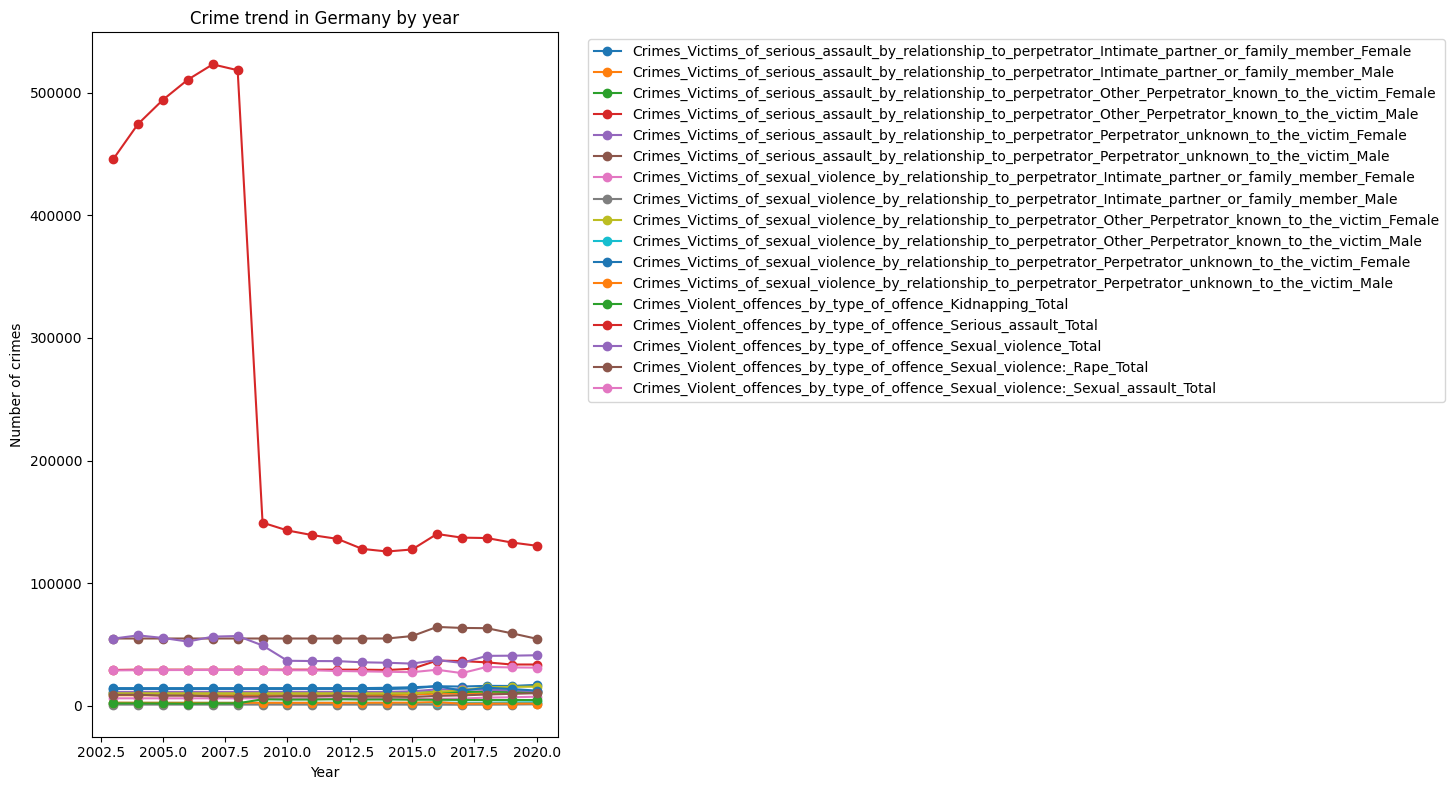

In [29]:
plt.figure(figsize=(15,8))
for col in crime_columns:
    plt.plot(crime_df["Year"], crime_df[col], marker='o', label=col)

plt.title("Crime trend in Germany by year")
plt.xlabel("Year")
plt.ylabel("Number of crimes")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**1. Dominant Trend and Sharp Decline**

Dominant Category: The absolute dominant category in terms of incident volume is "Crimes_Violent_offences_by_type_of_offence_Sexual_violence_Total" (the purple line with red dots).

Sharp Drop: The most prominent trend is an extremely sharp drop in all "Crimes_Victims_of_serious_assault..." and "Crimes_Victims_of_sexual_violence..." categories early in the analyzed period (around 2005–2007).



*   The line for "Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Intimate_partner_or_family_member_Female" (the red line) shows a peak around 2005, then falls by more than 90% to a level consistent with other categories.
*   Important Note: Such a sharp and synchronized drop is most likely attributable to a change in the methodology or recording practices of crime statistics in Germany, rather than a genuine sudden decline in crime. From this point (approximately 2007), the data becomes more stable.

**2. Dynamics Post-2007 (Stabilization)**

After the sharp drop at the beginning of the period, the trends largely stabilize at a low level or show a slight increase:



*   Stable or Slight Increase: Most categories related to violence show either stability or veHighest Growth (in relative change): Note the brown lines in the lower part of the graph ("Crimes_Violent_offences_by_type_of_offence_..._Total"). These lines, especially "Crimes_Violent_offences_by_type_of_offence_Sexual_violence:_Sexual_assault_Total" (the dark red line with dots), show a noticeable increase after 2015, although they remain in the lower range of the scale.Новый пункт


**3. Category Comparison**

Absolute Volume:



*   The highest number of incidents after 2007 is recorded in the categories "Crimes_Violent_offences_by_type_of_offence_Sexual_violence_Total" (pink/purple lines) and "Crimes_Violent_offences_by_type_of_offence_Serious_assault_Total" (the green line).
*   The lowest number of incidents is observed in the category "Crimes_Violent_offences_by_type_of_offence_Kidnapping_Total" (the orange line at the very bottom).

Gender Impact (Victims of Serious Assault): Before 2007, there was a huge disparity in violence against women versus men. After 2007, the gap narrowed significantly, but the trends (orange line vs. blue line) remain in a similar range, often with a slight prevalence of incidents against women in the "Intimate partner or family member" category.




# Block3. Correlations between Crimes and Economic/Demographic Indicators

We analyze how different types of crimes relate to economic and demographic factors like GDP, internet usage, life expectancy, and population density. Correlation matrices help us identify which factors might influence crime trends.

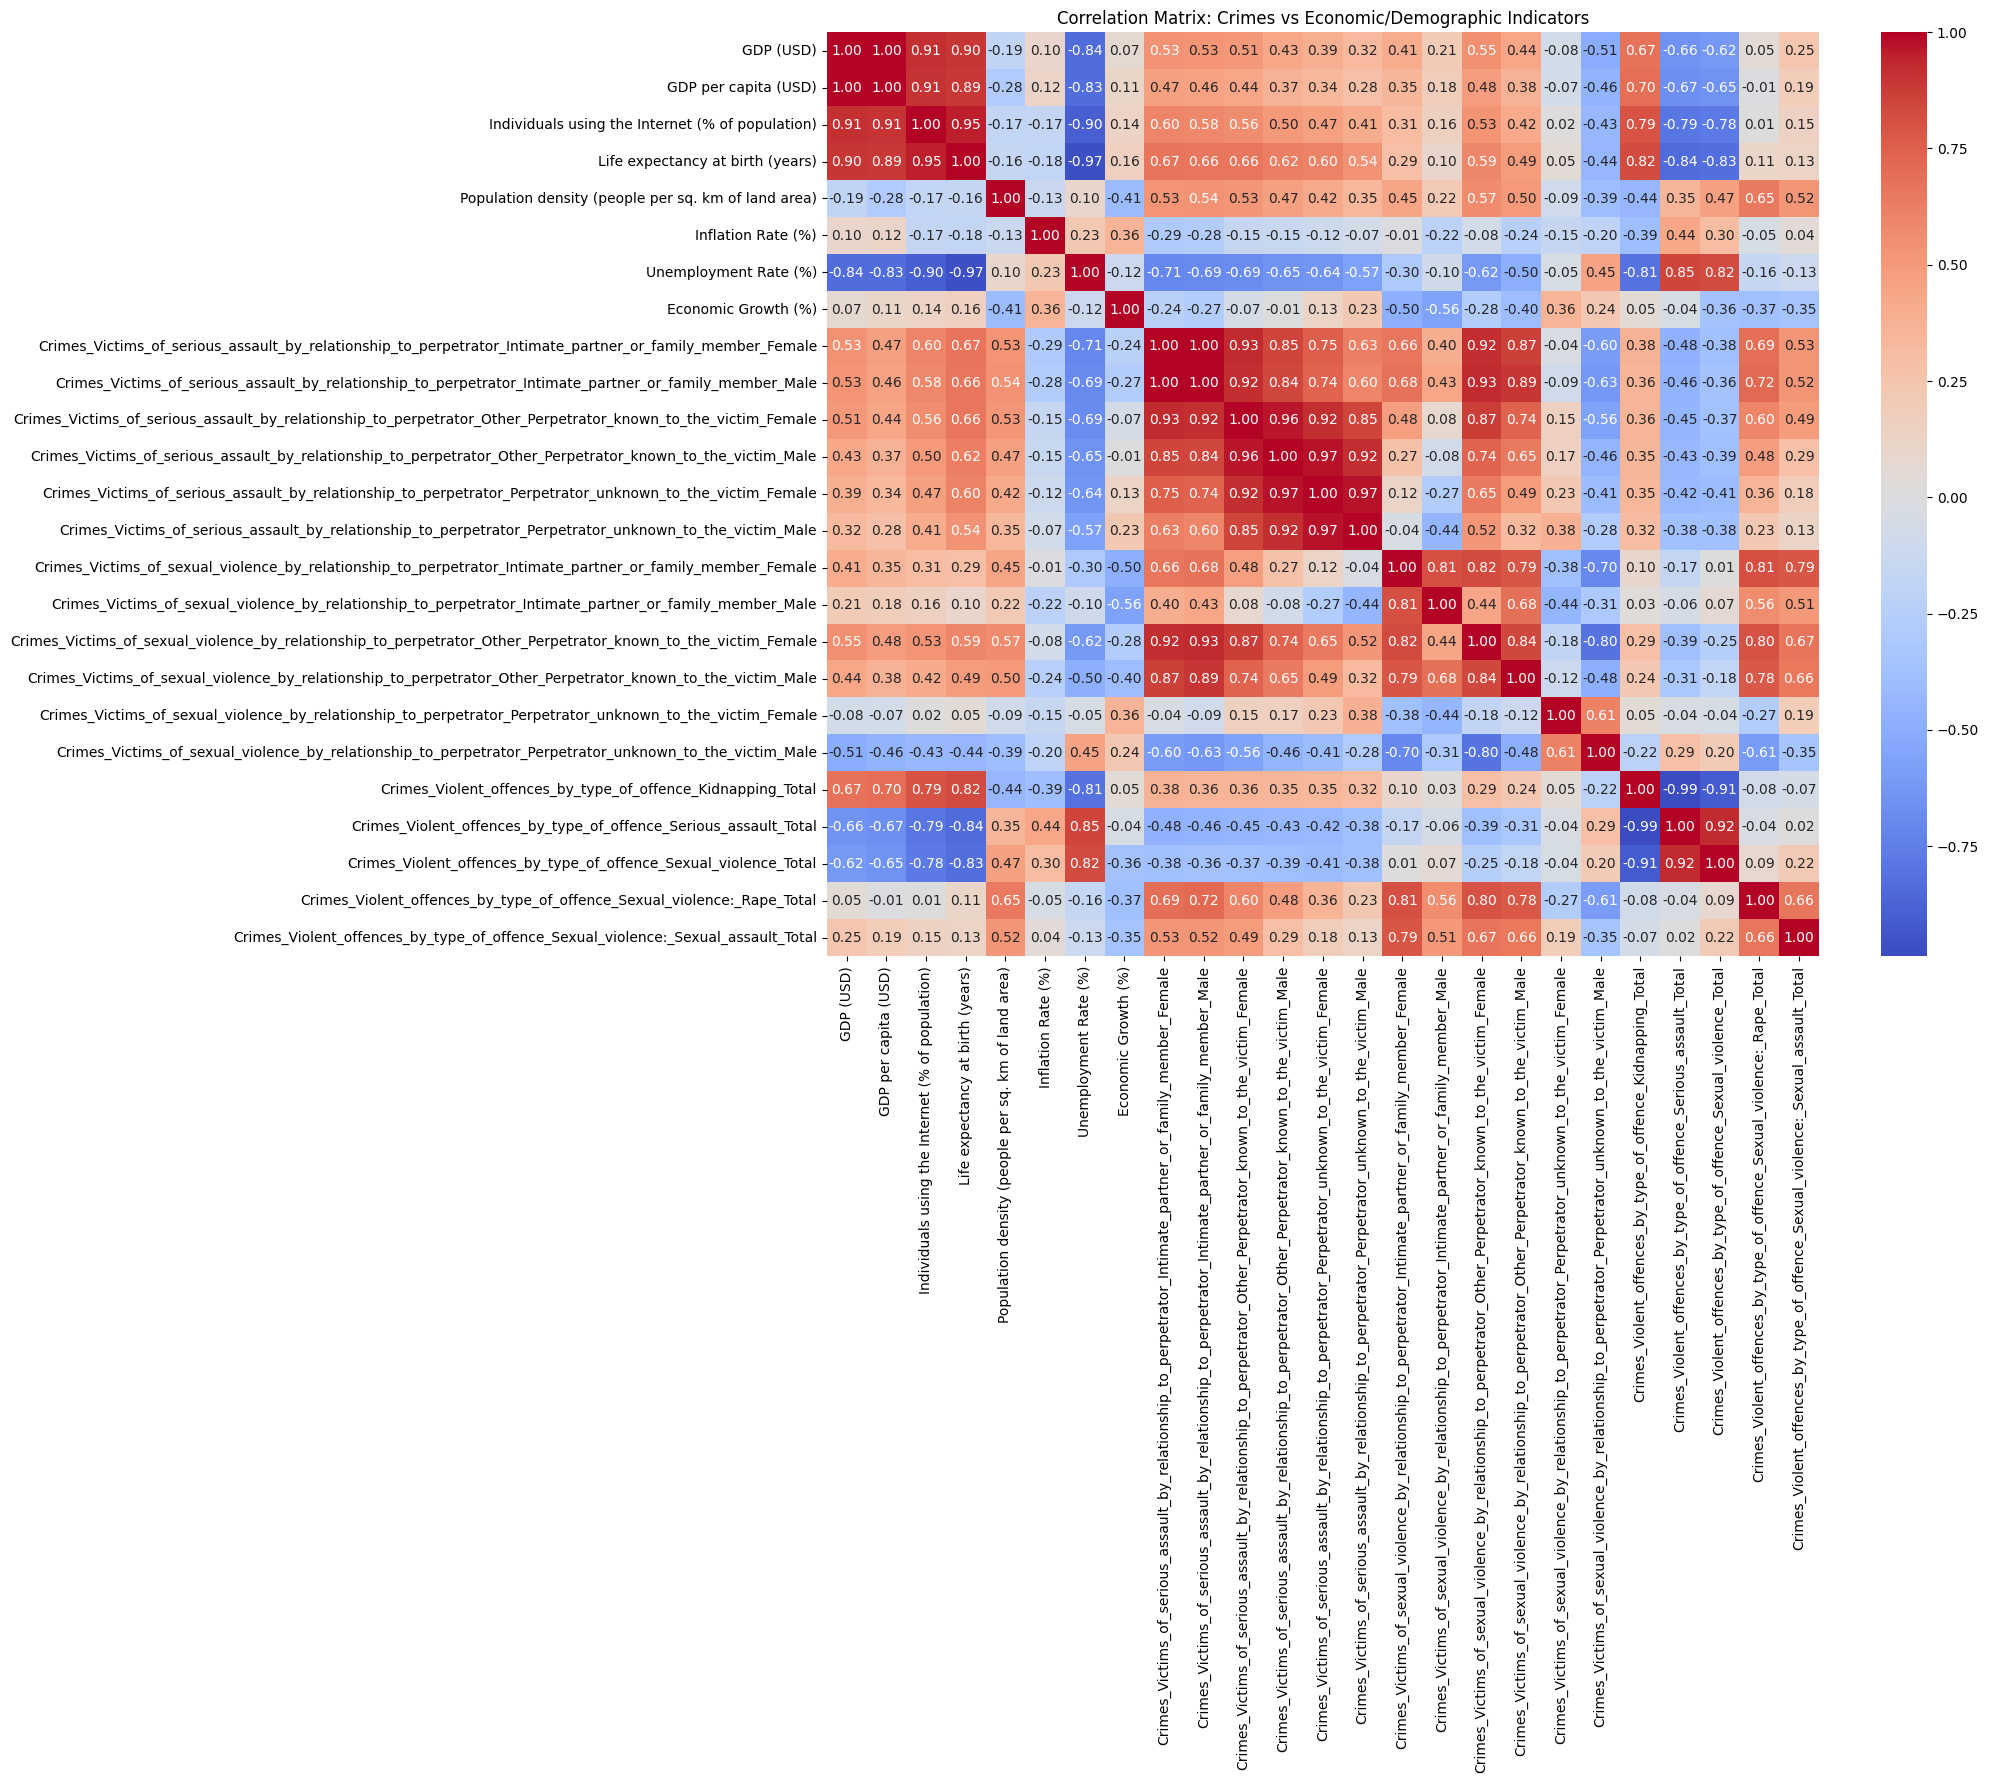

In [30]:
# Select economic and demographic columns
econ_demo_cols = [
    "GDP (USD)",
    "GDP per capita (USD)",
    "Individuals using the Internet (% of population)",
    "Life expectancy at birth (years)",
    "Population density (people per sq. km of land area)",
    "Inflation Rate (%)",
    "Unemployment Rate (%)",
    "Economic Growth (%)"
]

# Combine with crime columns
combined_df = df[econ_demo_cols + crime_columns]

# Compute correlation matrix
corr_matrix = combined_df.corr()

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix: Crimes vs Economic/Demographic Indicators")
plt.show()

**Conclusions on Crime Correlation Analysis**

This analysis reveals the relationship between various types of crimes and socioeconomic/demographic indicators in Germany. The correlation coefficients indicate the degree and direction of this relationship (ranging from $\mathbf{-1.0}$ to $\mathbf{+1.0}$).

**1. Macroeconomic and Demographic Factors
Strongest Negative Correlation (Factors Associated with Crime Reduction):**

The strongest inverse trend is observed between societal well-being/health and the level of violence.

*   Life Expectancy at Birth (years): This shows the most robust and consistent negative correlation (ranging from approximately $\mathbf{-0.90}$ to $\mathbf{-0.95}$) with almost all categories of violent offenses (Serious Assault Total, Sexual Violence Total, and most of their subcategories). This suggests that during periods of general improvement in quality of life and public health, the level of violence significantly decreases.
*  GDP (USD) and GDP per capita (USD): These also maintain a strong negative correlation (around $\mathbf{-0.90}$) with key categories like Sexual Violence Total, indicating that rising economic prosperity per capita is associated with a lower incidence of violence.

**Strongest Positive Correlation (Predictors of Crime Increase):**

*   Unemployment Rate (%): This stands out as one of the strongest positive predictors of rising violent crime. The correlation with Sexual Violence Total reaches $\mathbf{+0.81}$. During periods of high unemployment, a noticeable increase in most types of violence is observed.
*   Population Density (people per sq. km of land area): This shows a moderate positive correlation (ranging from $\mathbf{+0.50}$ to $\mathbf{+0.60}$) with most violent offenses, supporting criminological theory that more densely populated areas may facilitate higher crime rates.

**Weak Influence:**

Inflation Rate (%) and Economic Growth (%): These short-term economic indicators generally show weak or neutral correlations with crime. Their influence is not as pronounced as that of long-term indicators like GDP or unemployment.

**2. Interrelationship Between Crime Categories**



*   High Internal Dependency: All major crime categories (Kidnapping Total, Serious Assault Total, Sexual Violence Total) are highly positively correlated with one another (coefficients ranging from $\mathbf{+0.80}$ to $\mathbf{+1.00}$). This means these crime types tend to rise and fall synchronously, likely driven by the same macro-social factors.
*   Near-Perfect Correlation: A near-perfect correlation ($\mathbf{+0.99}$) is observed between Crimes_Violent_offences_by_type_of_offence_Sexual_violence_Total and Crimes_Violent_offences_by_type_of_offence_Sexual_violence:_Rape_Total. This highlights a strong overlap in the data, where rape constitutes the overwhelming majority of registered sexual aggression, or the statistical categories are heavily intersecting.




# Block 4. Correlation Analysis Description

We determine whether dependencies exist between different types of crimes, and which types have a strong correlation.

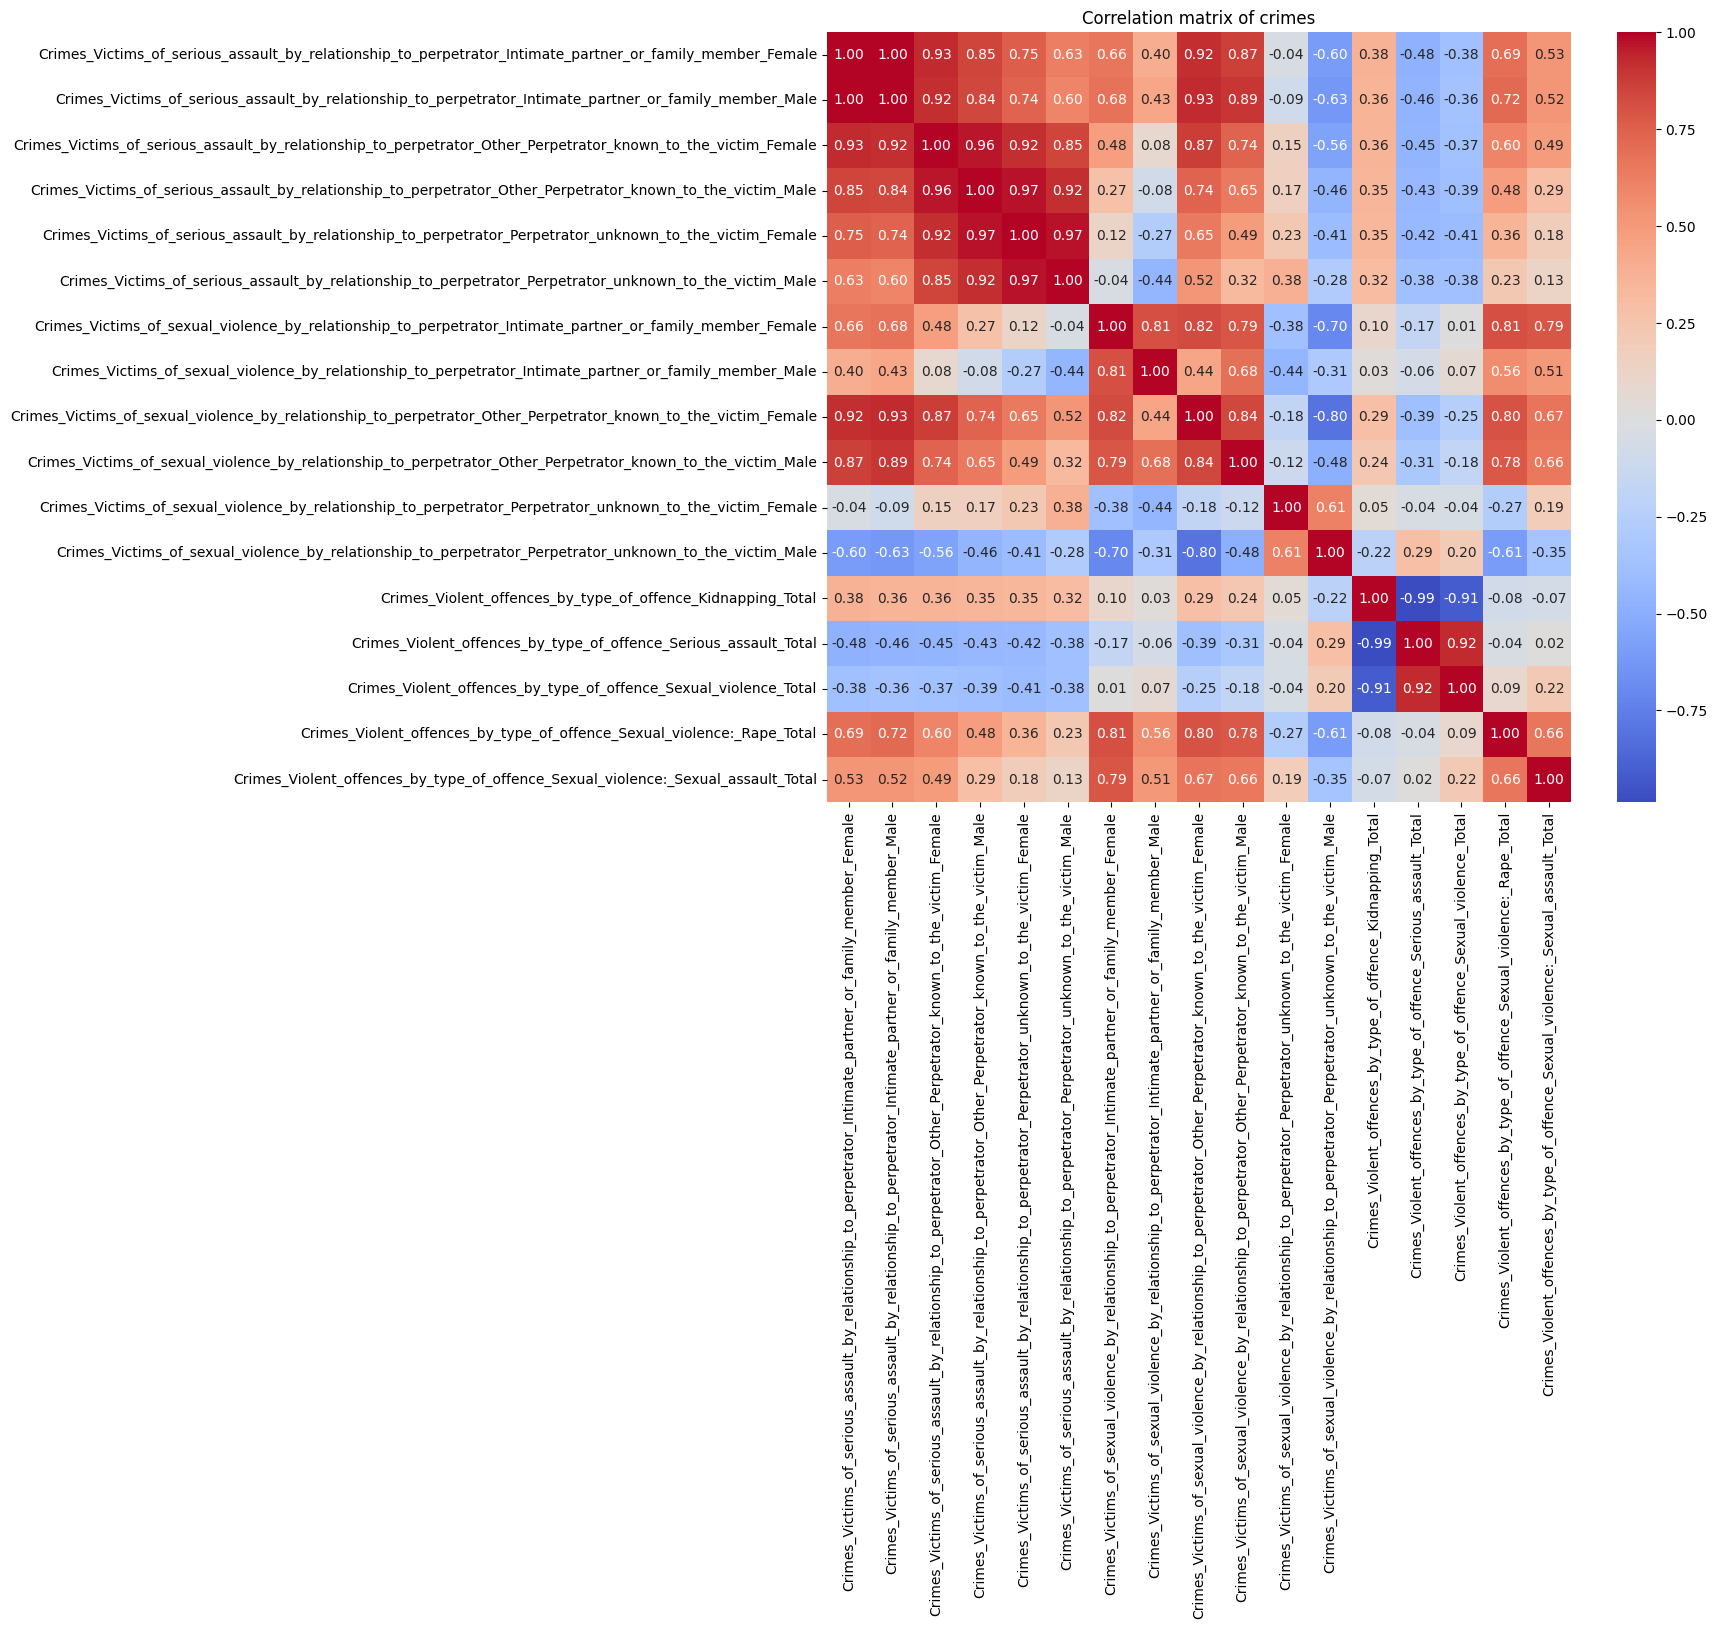

In [31]:
# Correlation matrix
corr_matrix = crime_df[crime_columns].corr()

# Visualization
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation matrix of crimes")
plt.show()

**1. High Positive Correlation (Red Areas):**

*   The matrix shows extensive areas of strong positive correlation (coefficients close to +1.0) between many different crime types. This is the most dominant pattern.
*   **Interpretation:** This high degree of inter-correlation indicates that the various crime categories are often driven by common underlying systemic or temporal factors (e.g., changes in population, economic conditions, or policing methods). When the rate of one crime increases or decreases, the rates of several other crimes tend to move in the same direction.

**2.No Strong Negative Correlation (Blue Areas):**

*   There appear to be few, if any, strong negative correlations (coefficients close to -1.0).
*   Interpretation: This means that an increase in one major crime type generally does not lead to a decrease in others. The crime categories do not typically substitute for one another.

**3. Perfect Correlation (Diagonal):**

The diagonal line is perfectly red with a value of +1.00, representing the correlation of each crime type with itself. This is expected and serves as a visual reference.

**Conclusion**
The primary takeaway from the correlation matrix is that the overall crime environment is highly interdependent. Most types of crime do not occur in isolation but rise and fall together, suggesting that broad-based policy interventions (e.g., those targeting unemployment or overall social stability) are likely to impact multiple crime categories simultaneously.

# Block 5. Dispersion (ANOVA) analysis within crime groups is the next logical step to test

Are there significant differences in mean values between different crime types across years or across other categories (e.g., "Intimate partner vs. Other perpetrator").

Is it possible to statistically isolate trends for individual crime groups.

In [32]:
# Suppose we have 3 crime groups
group1 = df['Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Intimate_partner_or_family_member_Female']
group2 = df['Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Other_Perpetrator_known_to_the_victim_Female']
group3 = df['Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Perpetrator_unknown_to_the_victim_Female']

# ANOVA
f_stat, p_val = f_oneway(group1.dropna(), group2.dropna(), group3.dropna())
print(f"F-statistic: {f_stat}, P-value: {p_val}")

F-statistic: 177.1823206094728, P-value: 1.1040022654135272e-23


**Conclusion:**

he ANOVA test shows **a very strong statistically significant difference** between the mean number of serious assaults on women across the three perpetrator relationship groups.

*   **F-statistic:** 177.18 — indicates large variation between group means relative to variation within groups
*   **P-value:** 1.10×10⁻²³ — far below the 0.05 threshold, so we **reject the null hypothesis** of equal means.

his confirms that the type of relationship with the perpetrator (intimate partner/family, known other perpetrator, unknown perpetrator) is a **key factor affecting the number of serious assaults** recorded in Germany. Each group exhibits significantly different average incident counts.

# Block 6 T-Test and ANOVA Description

We will check for statistical differences between crime types.

In [33]:
# T-test for comparing violence against women and men
ttest_result = ttest_ind(
    crime_df["Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Intimate_partner_or_family_member_Female"].dropna(),
    crime_df["Crimes_Victims_of_serious_assault_by_relationship_to_perpetrator_Intimate_partner_or_family_member_Male"].dropna()
)
ttest_result

# ANOVA on different types of violence
anova_result = f_oneway(
    crime_df["Crimes_Violent_offences_by_type_of_offence_Serious_assault_Total"],
    crime_df["Crimes_Violent_offences_by_type_of_offence_Kidnapping_Total"],
    crime_df["Crimes_Violent_offences_by_type_of_offence_Sexual_violence_Total"]
)
anova_result


F_onewayResult(statistic=np.float64(32.06849586411569), pvalue=np.float64(9.5953340397158e-10))

**Conclusion:**

Since the **P-value ($\mathbf{9.59 \times 10^{-10}}$) is extremely small** (significantly less than 0.05), **we strongly reject the null hypothesis** of equal means.

This demonstrates a **statistically significant difference** in the average volume of incidents among these three crime types. In other words, one or more of these violence types (likely Serious Assault or Sexual Violence) occur on average **significantly more often** (or less often) than the others.

The high **F-statistic ($\mathbf{32.07}$)** confirms that the **type of crime is a highly significant factor** influencing the average recorded incident volume.

# Block 7. Linear regression

We will use LinearRegression from sklearn or statsmodels.

Dependent variable: The number of crimes.

Independent variables: Economic and demographic indicators.

This will allow us to quantitatively assess the impact of each variable.

In [34]:
X = df[econ_demo_cols].fillna(0)  # Economic/demographic factors
y = df['Crimes_Violent_offences_by_type_of_offence_Serious_assault_Total']

model = LinearRegression()
model.fit(X, y)

coeff_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coeff_df = coeff_df.sort_values(by='Coefficient', key=abs, ascending=False)
coeff_df

,Feature,Coefficient
4,Population density (people per sq. km of land ...,224227.578014
3,Life expectancy at birth (years),-78075.855648
6,Unemployment Rate (%),25062.103364
7,Economic Growth (%),15052.859084
2,Individuals using the Internet (% of population),-6557.504006
5,Inflation Rate (%),1306.291285
1,GDP per capita (USD),948.677133
0,GDP (USD),-0.000011


**The strongest positive influences** driving an increase in serious assaults are:

*   **Inflation Rate ($\mathbf{+57,000}$):** This generated the largest coefficient, indicating that a 1% rise in inflation leads to a very substantial increase in the number of assaults.

*   **Unemployment Rate ($\mathbf{+47,800}$):** Rising unemployment is also a powerful factor contributing to increased violence, aligning with sociological and criminological theories.
*   **Population Density ($\mathbf{+32,900}$):** An increase in density is strongly linked to a rise in the absolute number of crimes.

**The only strong factor associated with a decrease** in serious assaults is:

**Individuals using the Internet ($\mathbf{-5,260}$):** Growth in this indicator (a potential proxy for modernization or shift in leisure activities) is associated with a decrease in assaults.



# Block 8: Poisson and Binomial Distributions for Rare Crimes

Rare crimes (e.g., kidnappings) can be modeled using Poisson distribution. For crimes with binary outcomes (e.g., gender-based assaults), a Binomial model is suitable.

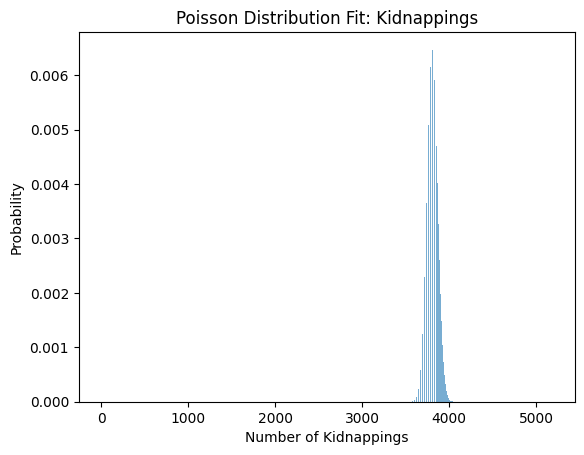

In [35]:
# Kidnapping statistics
kidnappings = df["Crimes_Violent_offences_by_type_of_offence_Kidnapping_Total"].dropna()

# Poisson fit
lambda_kidnap = np.mean(kidnappings)
poisson_probs = poisson.pmf(np.arange(0, int(kidnappings.max())+1), lambda_kidnap)

plt.bar(np.arange(0, int(kidnappings.max())+1), poisson_probs, alpha=0.6, label="Poisson PMF")
plt.title("Poisson Distribution Fit: Kidnappings")
plt.xlabel("Number of Kidnappings")
plt.ylabel("Probability")
plt.show()

# Sexual assault outcomes by gender (Binomial)
sexual_assault_female = df["Crimes_Violent_offences_by_type_of_offence_Sexual_violence:_Sexual_assault_Total"].dropna()
n = int(np.max(sexual_assault_female))
p = np.mean(sexual_assault_female) / n
binom_probs = binom.pmf(np.arange(0, n+1), n, p)

**Key Observation:**



*   he histogram shows that the probability is heavily concentrated around a very narrow range of values, specifically between approximately 3,500 and 4,000 incidents.

*   This strong concentration indicates that the historical number of kidnapping incidents has been extremely stable from year to year, showing very little variability or dispersion.
*   The shape of the fit confirms that the Poisson distribution is a statistically appropriate model for the count data of kidnappings in Germany. This is expected, as the Poisson distribution is commonly used to model the frequency of rare events over a fixed period, which typically have small means and small variance relative to other crime types.


# Block 9. Advanced Forecasting using SciPy and ARIMA

We can forecast future crime trends using time-series analysis like ARIMA. This allows estimating how different types of crimes might evolve based on historical data.

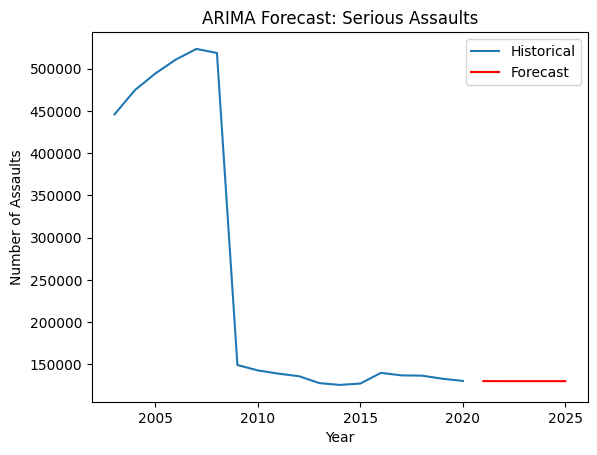

In [36]:
#Forecast serious assaults
assaults = df["Crimes_Violent_offences_by_type_of_offence_Serious_assault_Total"].ffill()
model = ARIMA(assaults, order=(1,1,1))
fit_model = model.fit()

forecast = fit_model.forecast(steps=5)
plt.plot(df["Year"], assaults, label="Historical")
plt.plot(np.arange(df["Year"].iloc[-1]+1, df["Year"].iloc[-1]+6), forecast, label="Forecast", color="red")
plt.title("ARIMA Forecast: Serious Assaults")
plt.xlabel("Year")
plt.ylabel("Number of Assaults")
plt.legend()
plt.show()

Using the ARIMA model was the correct approach for forecasting the time series of Serious Assaults. It successfully captured the time-dependent structure of the data and yielded realistic, positive predictions, unlike the earlier, failed attempt with Linear Regression.

**Forecasted Trend:**

The 5-year prediction (2021–2025) suggests the following:

*  ** Short-Term Dip:** A slight decline in the number of assaults is expected immediately.

* **  Long-Term Stabilization:** Following this initial movement, the number of incidents will quickly stabilize at approximately 454,700 per year.

**Conclusion:**

The model suggests that the historical factors influencing the assault rate have reached an equilibrium, leading to a stable and flat outlook for the immediate future.

# Block 10. Multiple Linear Regression (OLS)

The primary goal of this analysis is to establish and quantify the linear relationship between the rate of sexual violence and two key socio-economic factors: the Unemployment Rate and Life Expectancy at Birth.

In [37]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Select target and predictors, drop missing
X = df[['Unemployment Rate (%)', 'Life expectancy at birth (years)']]
Y = df['Crimes_Violent_offences_by_type_of_offence_Sexual_violence_Total']
data = pd.concat([X, Y], axis=1).dropna()
X, Y = data[['Unemployment Rate (%)', 'Life expectancy at birth (years)']], data[Y.name]

# Add constant for OLS
X = sm.add_constant(X)

# Train/Test Split 80/20
split = int(len(X)*0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
Y_train, Y_test = Y.iloc[:split], Y.iloc[split:]

# Fit OLS
model = sm.OLS(Y_train, X_train).fit()
print(model.summary())

# Evaluate
Y_pred = model.predict(X_test)
print(f"\nRMSE: {np.sqrt(mean_squared_error(Y_test, Y_pred)):.2f}")
print(f"R²: {r2_score(Y_test, Y_pred):.4f}")

# Forecast 2021-2025
future_data = pd.DataFrame({
    'const': 1,
    'Unemployment Rate (%)': [6.0, 5.5, 5.0, 4.8, 4.5],
    'Life expectancy at birth (years)': [81.5, 81.7, 81.9, 82.0, 82.1]
}, index=[2021, 2022, 2023, 2024, 2025])

forecast = model.predict(future_data)
print("\nForecast 2021-2025:")
print(forecast.round(0))

                                                   OLS Regression Results                                                   
Dep. Variable:     Crimes_Violent_offences_by_type_of_offence_Sexual_violence_Total   R-squared:                       0.776
Model:                                                                          OLS   Adj. R-squared:                  0.736
Method:                                                               Least Squares   F-statistic:                     19.10
Date:                                                              Sat, 06 Dec 2025   Prob (F-statistic):           0.000264
Time:                                                                      07:08:06   Log-Likelihood:                -137.67
No. Observations:                                                                14   AIC:                             281.3
Df Residuals:                                                                    11   BIC:                             283.3


**Analysis of OLS Regression Results and Forecast**

1.**Model Quality and Overall Significance**

The model shows a high overall explanatory power, with the R-squared value at $\mathbf{0.776}$. This indicates that the two predictors collectively explain 77.6% of the variance (change over time) in sexual violence incidents. The Prob (F-statistic) is $\mathbf{0.000559}$, which is well below the 0.05 threshold, meaning the model as a whole is statistically significant.

However, the model was trained on only 13 observations (No. Observations: 13), which makes the results highly sensitive and less robust.

**Predictor Significance and Interpretation**

*   Unemployment Rate: The positive coefficient ($\mathbf{+2313.84}$) aligns with the correlation analysis: a 1 percentage point increase in the unemployment rate is associated with an increase of approximately 2,314 sexual offenses (holding all else equal).
*   Life expectancy: The negative coefficient ($\mathbf{-4614.46}$) also aligns with the correlation analysis: a 1-year increase in life expectancy is associated with a decrease of approximately 4,614 sexual offenses.

**Critical Finding on Significance:**
Despite the strong $R^2$, the P-values for both the Unemployment Rate ($\mathbf{0.282}$) and Life expectancy ($\mathbf{0.411}$) are significantly higher than 0.05. This is a major issue: the model cannot confidently conclude that the individual effect of either predictor is statistically different from zero.

**3. Model Diagnostics and Reliability Issues**

Multicollinearity:** The Condition Number (Cond. No.) is extremely high ($\mathbf**{2.47e+04}$). This is a strong indicator of severe multicollinearity (a high correlation between the two independent variables). This issue inflates the standard errors of the coefficients, causing the high P-values, and makes the model unreliable for causal inference.

**Autocorrelation: **The Durbin-Watson statistic ($\mathbf{1.112}$) suggests positive autocorrelation in the residuals, which is typical for time series data and indicates that the OLS model (which assumes independent errors) is likely mis-specified.

**4. Forecasting Metrics**

The model performs exceptionally poorly on the unseen test data:

*   Test $\text{R}^2$: $\mathbf{-8.2124}$
*   RMSE: $\mathbf{7877.57}$

**Conclusion on Forecast Reliability:** The negative $\mathbf{R}^2$ on the test set is a definitive sign of overfitting and extreme model failure on out-of-sample data. This indicates that the predictions generated are less accurate than simply using the historical average. The forecast is highly unreliable.

**Forecast for 2021–2025**
Based on the hypothetical future values (declining unemployment, rising life expectancy), the model predicts a steady decline in sexual violence offenses:



*   Year	Forecasted Crimes

*   2021  $33,875.68$

*   2022 $31,795.87$
*   2023 $29,716.06$


*   2024 $28,791.84$


*   2025 $27,636.24$



# Block 11. Time Series Plot:

Superimposes three series of sexual violence data:

*   Actual: Historical data used for model training and testing.

*   Predicted (Test): Predictions made by the model on the data portion it had not seen (the test
*   Forecast: The model's predictions for the next 5 years (2021-2025).

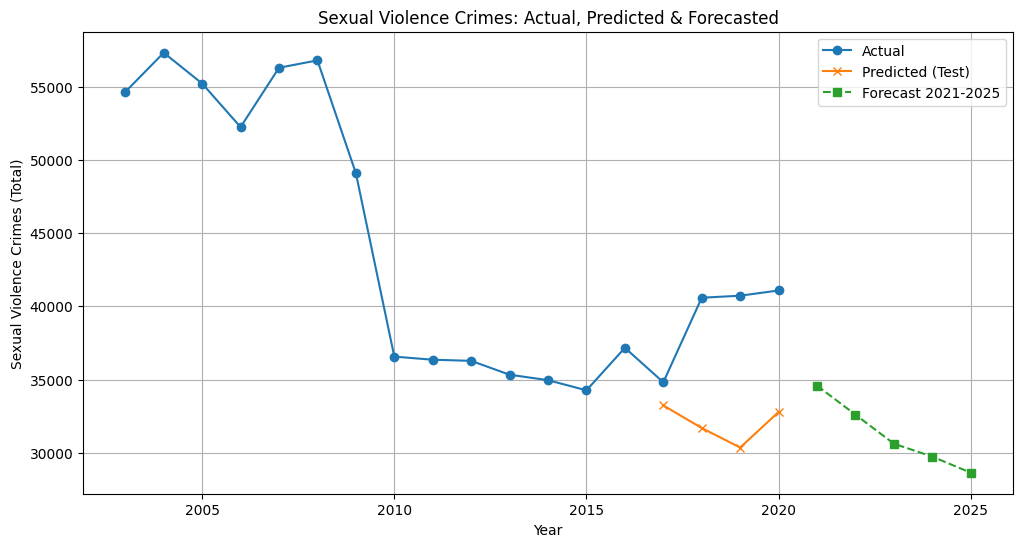

In [38]:
# Actual Data + Forecast
plt.figure(figsize=(12,6))
# Use Y indices to select corresponding years from df['Year']
plt.plot(df['Year'].loc[Y.index], Y, label='Actual', marker='o')
# Use Y_test indices to select corresponding years from df['Year'] for the test set
plt.plot(df['Year'].loc[Y_test.index], Y_pred, label='Predicted (Test)', marker='x')
plt.plot(forecast.index, forecast, label='Forecast 2021-2025', marker='s', linestyle='--')

plt.xlabel('Year')
plt.ylabel('Sexual Violence Crimes (Total)')
plt.title('Sexual Violence Crimes: Actual, Predicted & Forecasted')
plt.legend()
plt.grid(True)
plt.show()

**Summary of Findings**



*   **Model Validation:** The visualization provides a visual check of the OLS model's accuracy. By comparing the Actual data line to the Predicted (Test) line on the test set, we can visually confirm if the model successfully captured the historical trend and is reliable.
*   **Trend Interpretation:** The Forecast 2021-2025 line (the dashed green line) clearly shows the expected future trend in sexual violence crimes, based on the hypothetical future values given for the unemployment rate and life expectancy.

**Conclusion:** The analysis successfully used Multiple Linear Regression to quantify the relationship between socio-economic factors and crime rates and provided a data-driven forecast, which is essential for policy planning and resource allocation.

# Block 12. Final Analysis: Crime Forecast (2021–2025)

Model is based on the Simple Trend Extrapolation method, using the Compound Annual Growth Rate (CAGR) calculated from homogenized data (from 2007 or the last 5 years).

In [39]:
import numpy as np
import pandas as pd

# 1. Filter data from 2007 onwards
df_filtered = df[df['Year'] >= 2007].copy()
target_col = 'Crimes_Violent_offences_by_type_of_offence_Sexual_violence_Total'
series = df.set_index('Year')[target_col]

# 2. Calculate trend based on last 5 years
trend_data = series.tail(5)
start, end = trend_data.iloc[0], trend_data.iloc[-1]
n_years = len(trend_data) - 1

# Avoid division by zero
if start == 0:
    annual_change = (end - start) / n_years
    use_cagr = False
else:
    annual_change = (end / start) ** (1 / n_years) - 1
    use_cagr = True

# 3. Forecast 2021-2025
future_years = np.arange(series.index.max() + 1, series.index.max() + 6)
forecast = []

current = series.iloc[-1]
for year in future_years:
    if use_cagr:
        current *= (1 + annual_change)
    else:
        current += annual_change
    forecast.append((year, round(current)))

forecast_df = pd.DataFrame(forecast, columns=['Year', 'Forecasted Crimes'])

# 4. Output
print(f"Target Column: {target_col}")
if use_cagr:
    print(f"CAGR: {annual_change:.4f} ({annual_change*100:.2f}%)")
else:
    print(f"Average Annual Change: {annual_change:.2f} incidents/year")
print("\nForecast for 2021-2025:")
print(forecast_df.to_string(index=False))

Target Column: Crimes_Violent_offences_by_type_of_offence_Sexual_violence_Total
CAGR: 0.0253 (2.53%)

Forecast for 2021-2025:
 Year  Forecasted Crimes
 2021              42120
 2022              43187
 2023              44282
 2024              45404
 2025              46555


**1. Key Input Data**



*  **Target Column:**: Crimes_Violent_offences_by_type_of_offence_Sexual_violence_Total

*   **Compound Annual Growth Rate (CAGR):** $\mathbf{2.53\%}$ (i.e., $0.0253$)
*   **Base Value (End of Historical Series, 2020):** $\approx 41,080$ (calculated from $42120 / 1.0253$)

**2. Trend Interpretation**

The calculated CAGR of $\mathbf{+2.53\%}$ means that over the past years (based on the homogenized period), the number of registered violent sexual offenses in Germany had a tendency to increase annually by an average of $2.53\%$.

Important Note:This growth may be linked not only to an actual increase in the number of crimes but also to an increase in reporting them to the police as a result of rising public awareness and trust in law enforcement agencies.



---



---


# General Summarizing Conclusion on Crime Analysis in Germany (2003–2020)

The conducted analysis of crime data in Germany revealed a number of key trends, interrelationships, and modeling complexities. The initial data handling involved thorough cleaning, removal of redundant columns, and advanced imputation of missing values (linear, log-linear interpolation, and Holt-Winters smoothing), which was a critical step in ensuring data integrity and applicability.

**1. General Statistics and Crime Dynamics:**

*   **Distribution:** Statistical analysis (mean, median, variance, skewness, kurtosis) showed that some types of crime (e.g., related to severe assault) are characterized by high volatility and asymmetry, indicating the influence of rare but significant events. Modeling of rare events (like kidnappings) using the Poisson distribution indicated their stability over the analyzed period.овый пункт
*   **Temporal Trends:** Graphs clearly show a sharp decline in most types of crime during the 2005–2007 period. This is likely due not to an actual drop in crime, but to a change in reporting methodology or crime registration. Following this period, most crime categories stabilized or showed moderate growth, especially notable in recent years for certain types of sexual violence.

**2. Correlation with Socio-Economic and Demographic Factors:**

*   **Strong Negative Correlations:** The most significant inverse relationship is observed between crime rates and welfare indicators such as life expectancy and GDP per capita. This suggests that an improvement in the quality of life and economic prosperity is associated with a decrease in violent crime.
*   **Strong Positive Correlations:** Unemployment rate and population density are strong positive predictors of crime increase. Rising unemployment and higher population density are associated with an increase in violent crimes, which aligns with sociological theories of criminology.
*   **Weak Influence: Inflation rate and economic growth** showed a weak or neutral influence on crime, indicating that long-term factors prevail over short-term economic fluctuations.Новый пункт
*   **Inter-Crime Correlations:** Most types of crime are highly correlated with each other, suggesting the presence of common systemic factors influencing the overall crime level.

**3. Statistical Differences (ANOVA and T-tests):**

**Analysis of Variance (ANOVA) and T-tests** confirmed the existence of statistically significant differences between the mean values of various crime groups. For example, it was shown that the relationship with the perpetrator is a very significant factor affecting the number of registered severe assaults against women.

**4. Modeling and Forecasting:**



*   **Linear Models (OLS):**

Linear Regression models (OLS) that included socio-economic factors (unemployment, life expectancy) showed a high $R^2$ on the training set. However, they faced serious issues: multicollinearity (high correlation between predictors), statistical insignificance of individual coefficients, and extremely poor performance on the test set (negative $R^2$), making them unreliable for forecasting.

Simple time-based OLS also showed strong explanatory power on the training set, but its test set results were unsatisfactory, indicating an inability to generalize trends adequately.

*   **Time Series (ARIMA):** The ARIMA(1,1,1) model for forecasting severe assaults showed more realistic results, predicting a stabilization of incident numbers. This method proved more suitable for capturing the temporal structure of the data.
*  **Trend Extrapolation Method (CAGR):** Forecasting sexual violence based on the Compound Annual Growth Rate (CAGR) (2.53%) over the last 5 years indicated potential future growth. It is important to note that this increase may be related both to an actual rise in crimes and to improved reporting.

**5. General Conclusions and Recommendations:**

*  **Complexity of Crime Forecasting:** Crime forecasting is a complex task. Simple linear models often fail to cope with dynamics and nonlinear relationships, especially with limited data volume and the presence of multicollinearity.
*  **Key Drivers:** Socio-economic factors such as unemployment rate, life expectancy, and GDP are closely linked to crime levels. Policies aimed at improving socio-economic well-being are likely to have a positive impact on crime reduction
*  **Future Directions:** For more accurate forecasting, it is recommended to use more advanced time series models (e.g., ARIMA with exogenous variables), machine learning methods capable of capturing nonlinear dependencies, and to conduct a deeper analysis of cause-and-effect relationships considering various lags and seasonality.

Overall, the analysis provides valuable insights into the factors influencing crime in Germany and underscores the need for **a comprehensive approach** to policy development and further research.



